In [1]:
import h5py
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from neuralop.models import FNO

file_ext = "eval_single"

def fno_input_converter(
    sources: np.ndarray,
    shape: str = "sphere",
    dim: int = 2,
    lim: int = 3,
    res: int = 32,
):
    """Convert source parameters to FNO input format."""
    m, r0, size = np.split(sources, 3, axis=-1)
    n_sources, _ = r0.shape
    
    grid_x = np.linspace(-lim, lim, res)
    grid_y = np.linspace(-lim, lim, res)
    if dim > 2:
        grid_z = np.linspace(-lim, lim, res)
        grids = np.meshgrid(grid_x, grid_y, grid_z, indexing="xy")
    else:
        grids = np.meshgrid(grid_x, grid_y, indexing="xy")

    grid = np.concatenate([g.ravel()[:, None] for g in grids], axis=-1)
    input_data = np.zeros((res**dim, dim))

    for n in range(n_sources):
        if shape == "sphere":
            idx_in = np.where(
                np.linalg.norm(grid - r0[n], axis=1) <= size[n, 0]
            )[0]
        elif shape == "prism":
            idx_in = np.where(
                (np.abs(grid[:, 0] - r0[n, 0]) <= size[n, 0])
                & (np.abs(grid[:, 1] - r0[n, 1]) <= size[n, 1])
            )[0]
        else:
            raise ValueError("Unknown shape")

        input_data[idx_in] += m[n, :dim]

    return input_data

(10, 2, 64, 64)
[[[ -6.169749    11.079674     0.           0.14015219  -0.09787341
     0.           0.315979     0.315979    10.        ]
  [  7.056017    -4.3712626    0.           0.9098996   -0.9083961
     0.           0.42256364   0.42256364  10.        ]
  [  6.043676     5.966265     0.          -0.02519505  -0.2560059
     0.           0.43313214   0.43313214  10.        ]
  [  9.550757    19.74555      0.          -0.670302     0.89806026
     0.           0.12098971   0.12098971  10.        ]
  [ -4.424538    11.260311     0.           0.52431947  -0.8589535
     0.           0.12923501   0.12923501  10.        ]
  [ -7.972218    11.332513     0.          -0.5391512   -1.002815
     0.           0.42469314   0.42469314  10.        ]
  [-11.342561     2.3333452    0.           0.2672132    1.029772
     0.           0.36665934   0.36665934  10.        ]
  [ -0.51448345  19.881083     0.           0.2643984   -0.66471165
     0.           0.36156914   0.36156914  10.        ]

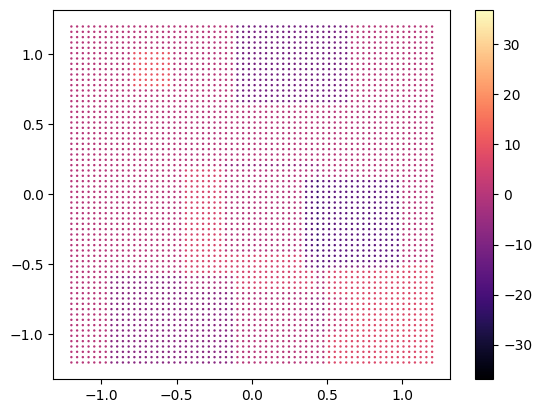

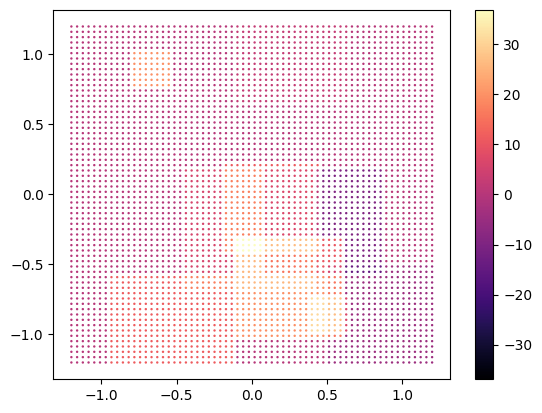

In [2]:
res = 64
idx = 1

if res == 128 or res == 64:
    res_out = res // 4
else:
    res_out = 32
lim = 1.2

datapath = Path.cwd() / ".." / "data"
figpath = Path.cwd() / ".." / "figs"
# db_name = "val_eval_large_m_92_1000_1"
# db_name = "eval_large_m_qt_42_10_50"
db_name = "eval_large_m_42_10_10"
figname = "fno_multi"

if file_ext == "eval_single":
    batch_size = 10
    db = h5py.File(datapath / f"{db_name}_fno_{res}.h5", "r")
    input = (
        np.array(db["input"][:batch_size])
        .reshape(batch_size, res, res, -1)
        .transpose(0, 3, 1, 2)
    )
    t_msp = np.array(db["output"][:batch_size]).reshape(
        batch_size, res_out, res_out
    )
else:
    if file_ext == "single":
        sources = np.load(datapath / f"sources_{file_ext}_9_2.npy")
        t_msp = np.load(datapath / f"gt_msp_grid_{file_ext}_9_2.npy")
    elif file_ext == "qt":
        sources = np.load(datapath / f"sources_{file_ext}_0_1.npy")
        t_msp = np.load(datapath / f"gt_msp_grid_{file_ext}_0_1.npy")
    else:
        sources = np.load(datapath / "sources_1_1.npy")
        t_msp = np.load(datapath / "gt_msp_grid_1_1.npy")

    # Check fno function
    input = fno_input_converter(sources, shape="prism", res=res, lim=1.2)

print(input.shape)
grids = np.meshgrid(
            np.linspace(-lim, lim, res),
            np.linspace(-lim, lim, res),
            np.linspace(0, 0, 1),
        )
grid = np.concatenate([g.ravel()[:, None] for g in grids], axis=-1)
x_grid = np.array(grid[:, 0].reshape((res, res)))
y_grid = np.array(grid[:, 1].reshape((res, res)))

# Plot example
if file_ext == "eval_single":
    db = h5py.File(datapath / f"{db_name}.h5", "r")
    sources = np.concatenate(
            [
                db["m"][idx:idx+1],
                db["r0"][idx:idx+1],
                db["size"][idx:idx+1],
            ],
            axis=-1,
        )
    db.close()
    print(sources)
    v_max = np.max(np.abs(np.sqrt(input[idx,0]**2 + input[idx,1]**2)))
    norm = mcolors.Normalize(vmin=-v_max, vmax=v_max)
    for i in range(2):
        contour = plt.scatter(x_grid, y_grid, c=input[idx, i].reshape((res, res)), cmap='magma', s=3, edgecolors='none', norm=norm)
        plt.colorbar(contour)
        plt.savefig(figpath / f"{figname}_input_{res}_plot_{idx}_{i}.png", dpi=300)
        # plt.savefig(figpath / f"{figname}_input_{res}_plot_{idx}_{i}.svg", format='svg')
        plt.show()
else:
    print(sources.shape)
    contour = plt.scatter(x_grid, y_grid, c=input[..., 0].reshape((res, res)), cmap='viridis', s=3, edgecolors='none')
    plt.colorbar(contour)

In [3]:
modelpath = Path.cwd() / ".." / "models" / "fno"
modelname = "fno_large_m_128_1M"
model = FNO.from_checkpoint(save_folder=modelpath, save_name=modelname)

if file_ext == "eval_single":
    input = torch.from_numpy(input.astype("float32"))
else:
    input = torch.from_numpy((
        np.array(input[None, :])
        .reshape(1, res, res, -1)
        .transpose(0, 3, 1, 2)).astype(np.float32)
    )
out = model(input).to("cpu").detach().numpy()
out = out.reshape(-1, res_out, res_out)
print(out.shape)

(10, 16, 16)


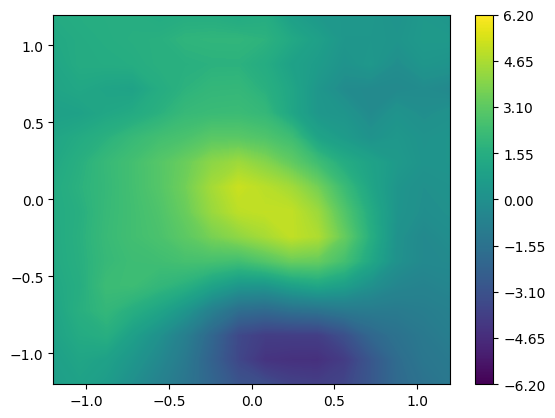

In [4]:
grids = np.meshgrid(
            np.linspace(-lim, lim, res_out),
            np.linspace(-lim, lim, res_out),
            np.linspace(0, 0, 1),
        )
grid_out = np.concatenate([g.ravel()[:, None] for g in grids], axis=-1)
x_grid_out = np.array(grid_out[:, 0].reshape((res_out, res_out)))
y_grid_out = np.array(grid_out[:, 1].reshape((res_out, res_out)))

if file_ext == "single":
    vmax = 2.5
elif file_ext == "qt":
    vmax = 4.5
elif file_ext == "eval_single":
    vmax = np.max(np.abs(t_msp[idx]))
else:
    vmax = 10
cbar_ticks = np.linspace(-vmax, vmax, 9)

norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)
levels = np.linspace(-vmax, vmax, 250)  # evenly spaced, symmetric levels
contour = plt.contourf(x_grid_out, y_grid_out, out[idx], levels=levels, cmap='viridis', norm=norm)
cbar = plt.colorbar(contour)
cbar.set_ticks(cbar_ticks)
plt.savefig(figpath / f"{figname}_out_{res}_plot_{idx}.png", dpi=300)
plt.savefig(figpath / f"{figname}_out_{res}_plot_{idx}.svg", format='svg')

(10, 16, 16)


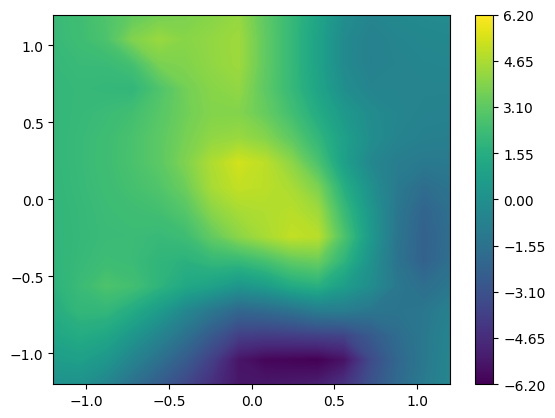

In [5]:
print(t_msp.shape)
if file_ext == "eval_single":
    contour = plt.contourf(x_grid_out, y_grid_out, t_msp[idx], levels=levels, cmap='viridis', norm=norm)
else:
    contour = plt.contourf(x_grid_out, y_grid_out, np.clip(t_msp, -vmax, vmax), levels=levels, cmap='viridis', norm=norm)
cbar = plt.colorbar(contour)
cbar.set_ticks(cbar_ticks)
plt.savefig(figpath / f"{figname}_gt_{res}_plot_{idx}.png", dpi=300)

Max: 0.23825286
Mean: 0.07928735
Median: 0.058134004


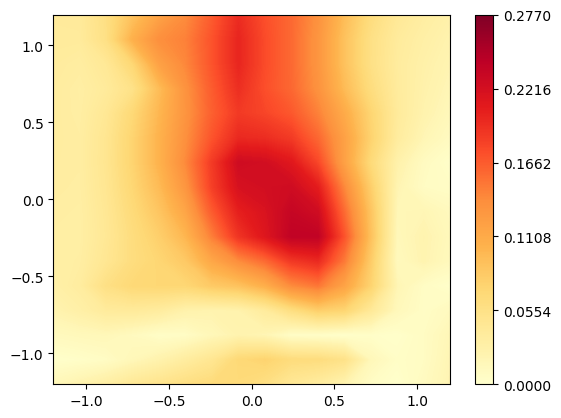

In [6]:
# Relative Error FNO
abs_err_fno = np.abs(np.array(out)[idx,0]  - t_msp[idx]) / v_max
print("Max:", np.max(abs_err_fno))
print("Mean:", np.mean(abs_err_fno))
print("Median:", np.median(abs_err_fno))
vmax_rel = v_max * 0.0075
vmin_rel = 0

levels_rel = np.linspace(vmin_rel, vmax_rel, 250)
contour_rel = plt.contourf(x_grid_out, y_grid_out, abs_err_fno, cmap="YlOrRd", levels=levels_rel)
cbar = plt.colorbar(contour_rel)
cbar.set_ticks(np.linspace(vmin_rel, vmax_rel, 6))
plt.savefig(figpath / f"{figname}_abs_err_{res}_plot_{idx}.png", dpi=300)

Max: 44562.855
Mean: 243.30519
Std 2780.1272
Median: 39.111954


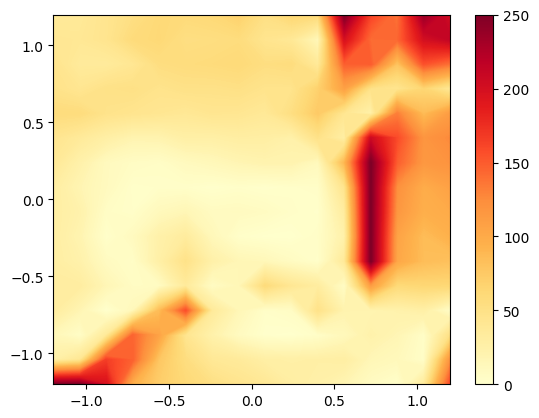

In [7]:
# Relative Error FNO
err_fno = ((np.abs(np.array(out)[idx]  - t_msp[idx])) / np.abs(t_msp[idx])) * 100
print("Max:", np.max(err_fno))
print("Mean:", np.mean(err_fno))
print("Std", np.std(err_fno))
print("Median:", np.median(err_fno))
vmax_rel = 250
vmin_rel = 0

levels_rel = np.linspace(vmin_rel, vmax_rel, 250)
# norm = mcolors.LogNorm(vmin=vmin_rel, vmax=vmax_rel)
norm = mcolors.Normalize(vmin=vmin_rel, vmax=vmax_rel)
contour_rel = plt.contourf(x_grid_out, y_grid_out, np.clip(err_fno, vmin_rel, vmax_rel), cmap="YlOrRd", levels=levels_rel, norm=norm)
cbar = plt.colorbar(contour_rel)
cbar.set_ticks(np.linspace(vmin_rel, vmax_rel, 6))
plt.savefig(figpath / f"{figname}_rel_err_{res}_plot_{idx}.png", dpi=300)

In [8]:
# Error full dataset
rel_err_pot = np.abs((t_msp - np.array(out)) / t_msp)
m_pot = np.nanmedian(rel_err_pot.reshape((-1, res_out**2)), axis=-1) * 100
print("Mean", np.mean(m_pot))
print("Std", np.std(m_pot))

Mean 45.477562
Std 10.347567
